In [1]:
import scanpy as sc
import pandas as pd

In [2]:
obs = sc.read_h5ad('/lustre/groups/ml01/workspace/hpca/hpca_downstream/2026_final_object_healthy_hvg.h5ad').obs

In [6]:
donor_metadata = obs.groupby('donor_id').first()

/tmp/ipykernel_2270189/559835129.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_metadata = obs.groupby('donor_id').first()


In [3]:
espace_bmi = pd.read_excel('/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/HPCA_ESPACE_Samples_metadata.xlsx')

In [4]:
espace_bmi.index= espace_bmi[' ESPACE identifier']

In [7]:
donor_metadata.loc[espace_bmi.index, 'BMI'] = espace_bmi['BMI']

In [4]:
sample_metadata = obs.groupby('ID').first()

/tmp/ipykernel_299020/2555670914.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_metadata = obs.groupby('ID').first()


In [5]:
sample_metadata

,barcode,Dataset,sample_id,donor_id,alignment_software,assay_ontology_term_id,institute,library_id,library_preparation_batch,library_sequencing_run,...,mapped_age_bin,BMI,BMI_category,HbA1c,age_from_hsapdv,ID_meta,n_counts,new_qc_passed,doublets,disease_status
ID,,,,,,,,,,,,,,,,,,,,,
AFES365,AAAGCAAAGAGTGAGA_11_AFES365,charite_snRNA,AFES365,AFHE365,Cellranger v3,EFO:0009899||EFO:0009922,NaN,AFHE365-body_nuc,0,0,...,HsapDv:0000240,NaN,NaN,NaN,"(50.0, 60.0)",AFES365,406.0,True,False,Control
AFES448,AAACCTGAGAAGGTGA_6_AFES448,charite_snRNA,AFES448,AFES448,Cellranger v3,EFO:0009899||EFO:0009922,NaN,AFES448-body_nuc,0,0,...,HsapDv:0000238,NaN,NaN,NaN,"(30.0, 40.0)",AFES448,784.0,True,False,Control
AGBR024,AAACCTGAGGCTCAGA_15_AGBR024,charite_snRNA,AGBR024,AGBR024,Cellranger v3,EFO:0009899||EFO:0009922,NaN,AGBR024-body_nuc,0,0,...,HsapDv:0000265,NaN,NaN,NaN,"(1.0, 5.0)",AGBR024,1119.0,True,False,Control
D1_D,D1_D_AGTCAACTCCTCATAT-1,Karakose,D1_D,R407,cellranger-6.1.0,EFO:0009922,Mount Sinai,R407_D,nan,nan,...,HsapDv:0000240,27.40,overweight,5.5,"(50.0, 60.0)",D1_D,95709.0,True,False,Control
D2_D,D2_D_ACTCCCACAGACCAGA-1,Karakose,D2_D,HP21226,cellranger-6.1.0,EFO:0009922,Mount Sinai,HP22126_D,nan,nan,...,HsapDv:0000239,NaN,NaN,NaN,"(40.0, 50.0)",D2_D,87444.0,True,False,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
islet_specimen_1,AAACCTGAGGTGTTAA-12_GSE183568,GSE183568,islet_specimen_1,DON184,STAR v2.6,EFO:0009899,NaN,"SRX12030187, SRX12030186, SRX12030185","library_SRX12030187, library_SRX12030186, libr...","process_SRX12030187, process_SRX12030186, proc...",...,HsapDv:0000264,24.13,normal,NaN,"(5.0, 15.0)",islet_specimen_1,6490.0,True,False,Control
islet_specimen_2,AAACCTGAGACCTAGG-9_GSE183568,GSE183568,islet_specimen_2,DON185,STAR v2.6,EFO:0009899,NaN,"SRX12030183, SRX12030182, SRX12030184","library_SRX12030183, library_SRX12030182, libr...","process_SRX12030183, process_SRX12030182, proc...",...,HsapDv:0000238,34.76,obese,NaN,"(30.0, 40.0)",islet_specimen_2,3359.0,True,False,Control
islet_specimen_3,AAACCTGGTCTGGAGA-1_GSE183568,GSE183568,islet_specimen_3,SAMN08768781,STAR v2.6,EFO:0009899,NaN,"SRX12030174, SRX12030175","library_SRX12030174, library_SRX12030175","process_SRX12030174, process_SRX12030175",...,HsapDv:0000240,22.40,normal,NaN,"(50.0, 60.0)",islet_specimen_3,5211.0,True,False,Control


In [9]:
donor_metadata['BMI']

donor_id
6229                  26.9
6234                  25.6
6278                  21.3
6282                  41.9
6339                  25.0
                      ... 
WFVY                  26.8
ZAHU                  32.8
donor_SAMN11633049     NaN
donor_SAMN11963659     NaN
donor_SAMN12227196     NaN
Name: BMI, Length: 109, dtype: float64

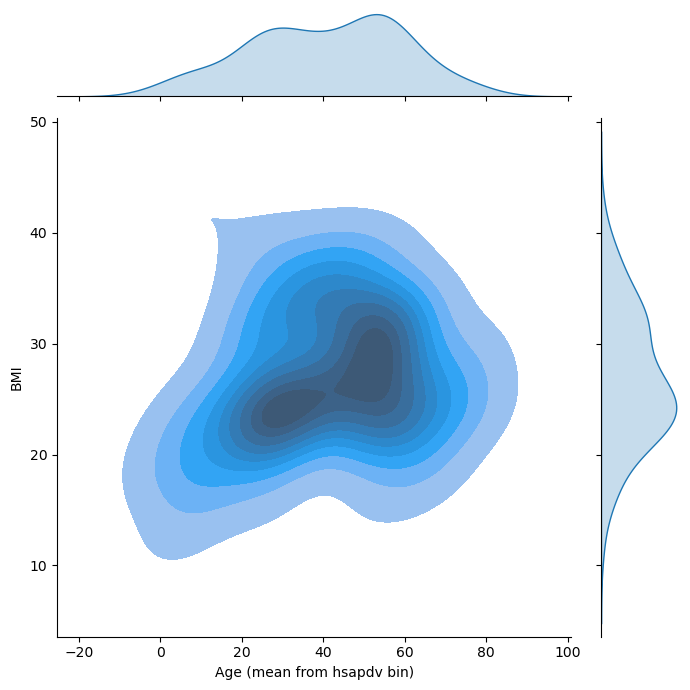

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Extract age bin as string from donor_metadata and compute mean age
def mean_from_interval(interval_str):
    # Remove any whitespace and parentheses
    vals = interval_str.strip('()').split(',')
    try:
        min_val = float(vals[0])
        max_val = float(vals[1])
        mean = (min_val + max_val) / 2
        return mean
    except Exception:
        return np.nan

# Compute mean age for each donor
age_col = 'age_from_hsapdv'  # adjust column name if needed; from output this appears correct
if donor_metadata[age_col].dtype != float:
    age_mean = donor_metadata[age_col].apply(mean_from_interval)
else:
    age_mean = donor_metadata[age_col]

# Extract BMI
bmi_col = 'BMI'  # Adjust column name if needed (ensure correct capitalization)
bmi = donor_metadata[bmi_col]

# Remove rows with missing (nan) ages or BMI
mask = (~age_mean.isna()) & (~bmi.isna())
age_mean = age_mean[mask]
bmi = bmi[mask]

# Create the jointplot (marginals are kdeplot when kind='kde'; do not pass bins=)
g = sns.jointplot(
    x=age_mean,
    y=bmi,
    kind='kde',
    fill=True,
    height=7,
    marginal_kws=dict(fill=True),
)

g.set_axis_labels('Age (mean from hsapdv bin)', 'BMI')
plt.tight_layout()
plt.savefig('/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/donor_metadata_plotting_healthy.svg', bbox_inches='tight')
plt.show()

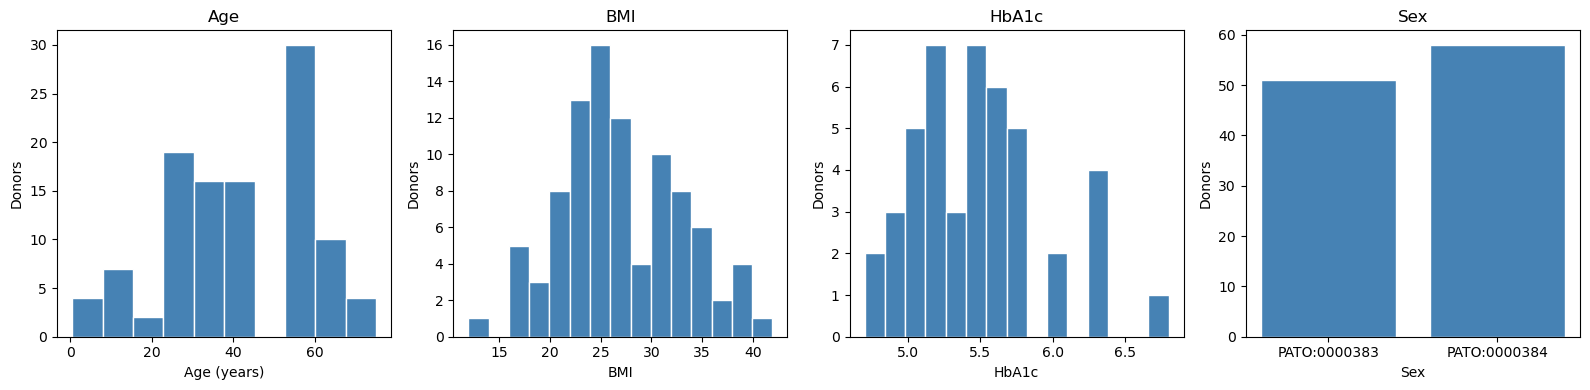

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Age (mean from hsapdv bin)
age_mean = donor_metadata['age_from_hsapdv'].apply(mean_from_interval).dropna()
axes[0].hist(age_mean, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Donors')
axes[0].set_title('Age')

# BMI
bmi = donor_metadata['BMI'].dropna()
axes[1].hist(bmi, bins=15, color='steelblue', edgecolor='white')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Donors')
axes[1].set_title('BMI')

# HbA1c
hba1c = donor_metadata['HbA1c'].dropna()
axes[2].hist(hba1c, bins=15, color='steelblue', edgecolor='white')
axes[2].set_xlabel('HbA1c')
axes[2].set_ylabel('Donors')
axes[2].set_title('HbA1c')

# Sex
sex_counts = donor_metadata['sex_ontology_term_id'].dropna().value_counts().sort_index()
axes[3].bar(sex_counts.index.astype(str), sex_counts.values, color='steelblue', edgecolor='white')
axes[3].set_xlabel('Sex')
axes[3].set_ylabel('Donors')
axes[3].set_title('Sex')

plt.tight_layout()
plt.savefig('/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/donor_histograms.svg', bbox_inches='tight')
plt.show()

In [9]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
import pandas as pd
import plotly.graph_objects as go

In [10]:
donor_metadata.assay.unique()

['10x 3′ v3', '10x 3′ v2 or 10x 3′ v3', '10x 3′ v2', '10x 3′ v1', 'inDrop', 'Drop-seq']
Categories (6, object): ['Drop-seq', 'inDrop', '10x 3′ v2', '10x 3′ v2 or 10x 3′ v3', '10x 3′ v1', '10x 3′ v3']

In [13]:
donor_metadata.Dataset.value_counts()

Dataset
HPAP                            27
espace_snRNA_adult_whole        16
GSE114297_remapped              12
Jimenez                         11
Karakose                         6
GSE101207_remapped               6
espace_scRNA_cultured_islets     5
GSE198623                        5
GSE183568                        5
GSE84133_remapped                4
espace_snRNA_frozen_islets       4
GSE150724                        3
charite_snRNA                    3
Tabula_Sapiens                   2
Name: count, dtype: int64

In [11]:
donor_metadata.loc[donor_metadata['assay'] == '10x 3′ v2 or 10x 3′ v3', 'assay'] = '10x 3′ v3'

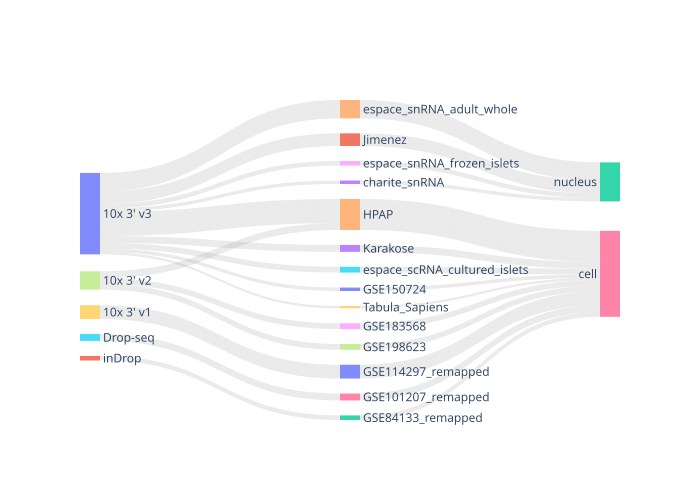

In [12]:


# Example DataFrame
df = donor_metadata[['suspension_type', 'Dataset', 'assay']]

# Create a list of all unique nodes
nodes = list(pd.unique(df[['assay', 'Dataset', 'suspension_type']].values.ravel()))

# Create a mapping from node names to indices
node_map = {node: i for i, node in enumerate(nodes)}

# Create the Sankey plot source (from) and target (to) lists
source = df['assay'].map(node_map).tolist() + df['Dataset'].map(node_map).tolist()
target = df['Dataset'].map(node_map).tolist() + df['suspension_type'].map(node_map).tolist()

# Create the value list (all values are 1 for this example, you can adjust it)
value = [1] * len(df) + [1] * len(df)

# Create the Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0),
        label=nodes,
    ),
    link=dict(
        source=source,  # Indices of the source nodes
        target=target,  # Indices of the target nodes
        value=value,     # Flow values
        color="rgba(150,150,150,0.2)",
    )
))

# Set plot title
#fig.update_layout(title_text="Sankey Diagram for Assay Ontology, Dataset, and Suspension Type", font_size=10)

# Show plot
fig.show(renderer='svg')
fig.write_image('/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/sankey_diagram.svg')